## Imports

In [1]:
import os
import glob
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score
import warnings
warnings.filterwarnings("ignore")

## Config

In [2]:
# Reproducibility
SEED = 420
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ---- Hyperparameters ----
NUM_POINTS = 8192
NUM_CLASSES = 14
BATCH_SIZE = 16
LR = 0.001
WEIGHT_DECAY = 1e-4
EPOCHS = 20
STEP_SIZE = 20
GAMMA = 0.5
PATIENCE = 25
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

Using device: cuda


## PLY reader

In [3]:
def read_ply(filepath):
    """Read ASCII .ply file, return xyz (N,3) float32 and labels (N,) int64."""
    with open(filepath, "r") as f:
        lines = f.readlines()

    header_end = 0
    num_vertices = 0
    prop_names = []
    for i, line in enumerate(lines):
        stripped = line.strip()
        if stripped.startswith("element vertex"):
            num_vertices = int(stripped.split()[-1])
        if stripped.startswith("property"):
            parts = stripped.split()
            prop_names.append(parts[-1])
        if stripped == "end_header":
            header_end = i + 1
            break

    x_idx = prop_names.index("x")
    y_idx = prop_names.index("y")
    z_idx = prop_names.index("z")
    label_idx = prop_names.index("scalar_Label")

    data_lines = lines[header_end: header_end + num_vertices]
    xyz = np.zeros((num_vertices, 3), dtype=np.float32)
    labels = np.zeros(num_vertices, dtype=np.int64)

    for j, dl in enumerate(data_lines):
        vals = dl.strip().split()
        xyz[j, 0] = float(vals[x_idx])
        xyz[j, 1] = float(vals[y_idx])
        xyz[j, 2] = float(vals[z_idx])
        labels[j] = int(float(vals[label_idx]))

    return xyz, labels

## Dataset

In [4]:
class PointCloudDataset(Dataset):
    def __init__(self, file_list, num_points=NUM_POINTS, augment=False):
        self.file_list = file_list
        self.num_points = num_points
        self.augment = augment

    def __len__(self):
        return len(self.file_list)

    @staticmethod
    def normalize(xyz):
        centroid = xyz.mean(axis=0)
        xyz = xyz - centroid
        max_dist = np.max(np.linalg.norm(xyz, axis=1))
        if max_dist > 1e-8:
            xyz = xyz / max_dist
        return xyz

    @staticmethod
    def random_rotation(xyz):
        angles = np.random.uniform(0, 2 * np.pi, size=3).astype(np.float32)
        cx, sx = np.cos(angles[0]), np.sin(angles[0])
        cy, sy = np.cos(angles[1]), np.sin(angles[1])
        cz, sz = np.cos(angles[2]), np.sin(angles[2])

        Rx = np.array([[1, 0, 0], [0, cx, -sx], [0, sx, cx]], dtype=np.float32)
        Ry = np.array([[cy, 0, sy], [0, 1, 0], [-sy, 0, cy]], dtype=np.float32)
        Rz = np.array([[cz, -sz, 0], [sz, cz, 0], [0, 0, 1]], dtype=np.float32)
        R = Rz @ Ry @ Rx
        return xyz @ R.T

    def __getitem__(self, idx):
        xyz, labels = read_ply(self.file_list[idx])

        n = xyz.shape[0]
        if n >= self.num_points:
            choice = np.random.choice(n, self.num_points, replace=False)
        else:
            choice = np.random.choice(n, self.num_points, replace=True)
        xyz = xyz[choice]
        labels = labels[choice]

        xyz = self.normalize(xyz)

        if self.augment:
            xyz = self.random_rotation(xyz)
            xyz += np.random.normal(0, 0.005, xyz.shape).astype(np.float32)

        return torch.from_numpy(xyz), torch.from_numpy(labels)

## PointNet++ implementaion

In [5]:
def square_distance(src, dst):
    """Pairwise squared Euclidean distance. src: (B,N,3), dst: (B,M,3) -> (B,N,M)."""
    dist = -2.0 * torch.matmul(src, dst.permute(0, 2, 1))
    dist += torch.sum(src ** 2, dim=-1, keepdim=True)
    dist += torch.sum(dst ** 2, dim=-1, keepdim=True).permute(0, 2, 1)
    return torch.clamp(dist, min=0.0)


def index_points(points, idx):
    """Gather points by index. points: (B,N,C), idx: (B,...) -> (B,...,C)."""
    B = points.shape[0]
    view_shape = list(idx.shape)
    view_shape[1:] = [1] * (len(view_shape) - 1)
    repeat_shape = list(idx.shape)
    repeat_shape[0] = 1
    batch_indices = torch.arange(B, dtype=torch.long, device=points.device) \
        .view(view_shape).repeat(repeat_shape)
    return points[batch_indices, idx, :]


def farthest_point_sample(xyz, npoint):
    """Iterative FPS. xyz: (B,N,3) -> (B,npoint) long indices."""
    B, N, _ = xyz.shape
    centroids = torch.zeros(B, npoint, dtype=torch.long, device=xyz.device)
    distance = torch.full((B, N), 1e10, dtype=torch.float32, device=xyz.device)
    farthest = torch.randint(0, N, (B,), dtype=torch.long, device=xyz.device)
    batch_idx = torch.arange(B, dtype=torch.long, device=xyz.device)

    for i in range(npoint):
        centroids[:, i] = farthest
        centroid = xyz[batch_idx, farthest, :].unsqueeze(1)
        dist = torch.sum((xyz - centroid) ** 2, dim=-1)
        distance = torch.min(distance, dist)
        farthest = torch.max(distance, dim=-1)[1]

    return centroids


def ball_query(radius, nsample, xyz, new_xyz):
    """Ball query. xyz: (B,N,3), new_xyz: (B,S,3) -> (B,S,nsample) long indices."""
    sqrdists = square_distance(new_xyz, xyz)  # (B, S, N)
    rsq = radius ** 2

    # Sort and take nsample closest
    sorted_dists, sorted_idx = torch.sort(sqrdists, dim=-1)
    sorted_dists = sorted_dists[:, :, :nsample]
    sorted_idx = sorted_idx[:, :, :nsample]

    # Replace points outside radius with first (nearest) neighbor
    mask = sorted_dists > rsq
    first = sorted_idx[:, :, 0:1].expand_as(sorted_idx)
    sorted_idx[mask] = first[mask]

    return sorted_idx


class SetAbstraction(nn.Module):
    """PointNet++ Set Abstraction module (Single-Scale Grouping)."""
    def __init__(self, npoint, radius, nsample, in_channel, mlp_channels):
        super().__init__()
        self.npoint = npoint
        self.radius = radius
        self.nsample = nsample

        layers = []
        last_ch = in_channel + 3  # +3 for local xyz coords
        for out_ch in mlp_channels:
            layers.append(nn.Conv2d(last_ch, out_ch, 1, bias=False))
            layers.append(nn.BatchNorm2d(out_ch))
            layers.append(nn.ReLU(inplace=True))
            last_ch = out_ch
        self.mlp = nn.Sequential(*layers)

    def forward(self, xyz, points):
        """
        xyz:    (B, N, 3)
        points: (B, N, C) or None
        Returns: new_xyz (B, npoint, 3), new_points (B, npoint, C')
        """
        fps_idx = farthest_point_sample(xyz, self.npoint)
        new_xyz = index_points(xyz, fps_idx)

        idx = ball_query(self.radius, self.nsample, xyz, new_xyz)
        grouped_xyz = index_points(xyz, idx) - new_xyz.unsqueeze(2)

        if points is not None:
            grouped_feats = index_points(points, idx)
            grouped_feats = torch.cat([grouped_xyz, grouped_feats], dim=-1)
        else:
            grouped_feats = grouped_xyz

        # (B, npoint, nsample, C_in) -> (B, C_in, nsample, npoint) for Conv2d
        grouped_feats = grouped_feats.permute(0, 3, 2, 1).contiguous()
        grouped_feats = self.mlp(grouped_feats)
        new_points = torch.max(grouped_feats, dim=2)[0]  # (B, C_out, npoint)
        new_points = new_points.permute(0, 2, 1).contiguous()

        return new_xyz, new_points


class FeaturePropagation(nn.Module):
    """PointNet++ Feature Propagation (upsampling via 3-NN inverse-distance interpolation)."""
    def __init__(self, in_channel, mlp_channels):
        super().__init__()
        layers = []
        last_ch = in_channel
        for out_ch in mlp_channels:
            layers.append(nn.Conv1d(last_ch, out_ch, 1, bias=False))
            layers.append(nn.BatchNorm1d(out_ch))
            layers.append(nn.ReLU(inplace=True))
            last_ch = out_ch
        self.mlp = nn.Sequential(*layers)

    def forward(self, xyz1, xyz2, points1, points2):
        """
        xyz1:    (B, N, 3)  — target (more points)
        xyz2:    (B, S, 3)  — source (fewer points)
        points1: (B, N, C1) — skip features or None
        points2: (B, S, C2) — features to upsample
        Returns: (B, N, C_out)
        """
        B, N, _ = xyz1.shape
        _, S, _ = xyz2.shape

        if S == 1:
            interp = points2.repeat(1, N, 1)
        else:
            dists = square_distance(xyz1, xyz2)  # (B, N, S)
            dists, idx = dists.sort(dim=-1)
            dists, idx = dists[:, :, :3], idx[:, :, :3]

            dist_recip = 1.0 / (dists + 1e-6)
            weight = dist_recip / dist_recip.sum(dim=-1, keepdim=True)
            interp = torch.sum(index_points(points2, idx) * weight.unsqueeze(-1), dim=2)

        if points1 is not None:
            cat_feats = torch.cat([points1, interp], dim=-1)
        else:
            cat_feats = interp

        cat_feats = cat_feats.permute(0, 2, 1).contiguous()
        cat_feats = self.mlp(cat_feats)
        return cat_feats.permute(0, 2, 1).contiguous()

## PointNet++

In [6]:
class PointNet2SemSeg(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        # Encoder
        self.sa1 = SetAbstraction(2048, 0.1, 32, 0,   [32, 32, 64])
        self.sa2 = SetAbstraction(512,  0.2, 32, 64,  [64, 64, 128])
        self.sa3 = SetAbstraction(128,  0.4, 32, 128, [128, 128, 256])
        self.sa4 = SetAbstraction(32,   0.8, 32, 256, [256, 256, 512])

        # Decoder
        self.fp4 = FeaturePropagation(512 + 256, [256, 256])
        self.fp3 = FeaturePropagation(256 + 128, [256, 128])
        self.fp2 = FeaturePropagation(128 + 64,  [128, 128])
        self.fp1 = FeaturePropagation(128 + 3,   [128, 128])

        # Head
        self.head = nn.Sequential(
            nn.Conv1d(128, 128, 1, bias=False),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Conv1d(128, num_classes, 1)
        )

    def forward(self, xyz):
        """xyz: (B, N, 3) -> logits (B, N, num_classes)"""
        l0_xyz = xyz
        l0_points = xyz.clone()

        l1_xyz, l1_points = self.sa1(l0_xyz, None)
        l2_xyz, l2_points = self.sa2(l1_xyz, l1_points)
        l3_xyz, l3_points = self.sa3(l2_xyz, l2_points)
        l4_xyz, l4_points = self.sa4(l3_xyz, l3_points)

        l3_points = self.fp4(l3_xyz, l4_xyz, l3_points, l4_points)
        l2_points = self.fp3(l2_xyz, l3_xyz, l2_points, l3_points)
        l1_points = self.fp2(l1_xyz, l2_xyz, l1_points, l2_points)
        l0_points = self.fp1(l0_xyz, l1_xyz, l0_points, l1_points)

        out = l0_points.permute(0, 2, 1)
        out = self.head(out)
        return out.permute(0, 2, 1)


## Data preparation

In [7]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
all_files = sorted(glob.glob(os.path.join("/content/drive/MyDrive/ДЗ_Дьяченко/term_2/task_2_dgcnn/dataset", "valve_*_lidar_classes.ply")))
print(f"Found {len(all_files)} PLY files")

random.shuffle(all_files)
n_train = int(0.70 * len(all_files))
n_val   = int(0.15 * len(all_files))

train_files = all_files[:n_train]
val_files   = all_files[n_train:n_train + n_val]
test_files  = all_files[n_train + n_val:]
print(f"Train: {len(train_files)}, Val: {len(val_files)}, Test: {len(test_files)}")

train_ds = PointCloudDataset(train_files, augment=True)
val_ds   = PointCloudDataset(val_files,   augment=False)
test_ds  = PointCloudDataset(test_files,  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True, drop_last=False)

# Class weights from training data
print("Computing class weights from training data...")
class_counts = np.zeros(NUM_CLASSES, dtype=np.float64)
for f in train_files:
    _, lbl = read_ply(f)
    for c in range(NUM_CLASSES):
        class_counts[c] += np.sum(lbl == c)

class_freq = class_counts / class_counts.sum()
class_weights = 1.0 / (class_freq + 1e-6)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print(f"Class weights: {class_weights.cpu().numpy().round(3)}")

Found 500 PLY files
Train: 350, Val: 75, Test: 75
Computing class weights from training data...
Class weights: [0.319 1.117 1.193 0.826 0.985 1.957 0.396 1.373 1.627 1.2   1.22  0.845
 0.628 0.313]


## Metrics

In [9]:
def compute_metrics(all_preds, all_labels, num_classes=NUM_CLASSES):
    oa = (all_preds == all_labels).sum() / len(all_labels)
    ious = []
    for c in range(num_classes):
        pred_c = (all_preds == c)
        true_c = (all_labels == c)
        intersection = (pred_c & true_c).sum()
        union = (pred_c | true_c).sum()
        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append(intersection / union)
    ious = np.array(ious)
    miou = np.nanmean(ious)
    return oa, miou, ious


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    count = 0

    for xyz, labels in loader:
        xyz, labels = xyz.to(DEVICE), labels.to(DEVICE)
        logits = model(xyz)
        loss = F.cross_entropy(logits.reshape(-1, NUM_CLASSES),
                               labels.reshape(-1),
                               weight=class_weights)
        total_loss += loss.item() * xyz.size(0)
        count += xyz.size(0)

        preds = logits.argmax(dim=-1).cpu().numpy().flatten()
        lbls  = labels.cpu().numpy().flatten()
        all_preds.append(preds)
        all_labels.append(lbls)

    all_preds  = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    avg_loss = total_loss / count
    oa, miou, ious = compute_metrics(all_preds, all_labels)
    return avg_loss, oa, miou, ious, all_preds, all_labels


## Training loop

In [10]:
for xyz, labels in train_loader:
    print("xyz shape:", xyz.shape)
    print("labels shape:", labels.shape)
    print("labels dtype:", labels.dtype)
    print("min label:", labels.min().item())
    print("max label:", labels.max().item())
    print("unique labels:", torch.unique(labels))
    break


xyz shape: torch.Size([16, 8192, 3])
labels shape: torch.Size([16, 8192])
labels dtype: torch.int64
min label: 0
max label: 13
unique labels: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13])


In [11]:
model = PointNet2SemSeg(NUM_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,}")

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=STEP_SIZE, gamma=GAMMA)

best_miou = 0.0
epochs_no_improve = 0
history = {"train_loss": [], "val_loss": [], "val_oa": [], "val_miou": []}

print("\n=== Training starts ===")
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    n_samples = 0

    for xyz, labels in train_loader:
        xyz, labels = xyz.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)

        logits = model(xyz)
        loss = F.cross_entropy(logits.reshape(-1, NUM_CLASSES),
                               labels.reshape(-1),
                               weight=class_weights)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimizer.step()

        running_loss += loss.item() * xyz.size(0)
        n_samples += xyz.size(0)

    train_loss = running_loss / n_samples
    scheduler.step()

    val_loss, val_oa, val_miou, val_ious, _, _ = evaluate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_oa"].append(val_oa)
    history["val_miou"].append(val_miou)

    lr_now = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:3d}/{EPOCHS} | "
          f"LR {lr_now:.6f} | "
          f"Train Loss {train_loss:.4f} | "
          f"Val Loss {val_loss:.4f} | "
          f"Val OA {val_oa:.4f} | "
          f"Val mIoU {val_miou:.4f}")

    if val_miou > best_miou:
        best_miou = val_miou
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_pointnet2_semseg.pth")
        print(f"  -> New best mIoU: {best_miou:.4f}, model saved.")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
        break

print(f"\nBest validation mIoU: {best_miou:.4f}")

Model parameters: 841,006

=== Training starts ===
Epoch   1/20 | LR 0.001000 | Train Loss 2.0615 | Val Loss 3.0003 | Val OA 0.1701 | Val mIoU 0.0121
  -> New best mIoU: 0.0121, model saved.
Epoch   2/20 | LR 0.001000 | Train Loss 1.4515 | Val Loss 7.4290 | Val OA 0.1696 | Val mIoU 0.0121
Epoch   3/20 | LR 0.001000 | Train Loss 1.2188 | Val Loss 9.0023 | Val OA 0.1700 | Val mIoU 0.0121
Epoch   4/20 | LR 0.001000 | Train Loss 0.9752 | Val Loss 6.2796 | Val OA 0.1785 | Val mIoU 0.0271
  -> New best mIoU: 0.0271, model saved.
Epoch   5/20 | LR 0.001000 | Train Loss 0.8431 | Val Loss 1.4237 | Val OA 0.6128 | Val mIoU 0.3851
  -> New best mIoU: 0.3851, model saved.
Epoch   6/20 | LR 0.001000 | Train Loss 0.7443 | Val Loss 1.1299 | Val OA 0.6415 | Val mIoU 0.4538
  -> New best mIoU: 0.4538, model saved.
Epoch   7/20 | LR 0.001000 | Train Loss 0.6959 | Val Loss 1.5867 | Val OA 0.5684 | Val mIoU 0.4027
Epoch   8/20 | LR 0.001000 | Train Loss 0.6771 | Val Loss 0.9657 | Val OA 0.6715 | Val mIoU 

## Test Evaluation

In [12]:
print("\n=== Evaluating on Test Set ===")
model.load_state_dict(torch.load("best_pointnet2_semseg.pth", map_location=DEVICE))

test_loss, test_oa, test_miou, test_ious, test_preds, test_labels = evaluate(model, test_loader)

test_f1 = f1_score(test_labels, test_preds, average="macro", zero_division=0)
cm = confusion_matrix(test_labels, test_preds, labels=list(range(NUM_CLASSES)))

print(f"\nTest Overall Accuracy : {test_oa:.4f}")
print(f"Test mIoU             : {test_miou:.4f}")
print(f"Test F1 (Macro)       : {test_f1:.4f}")
print(f"\nPer-Class IoU:")
for c in range(NUM_CLASSES):
    iou_str = f"{test_ious[c]:.4f}" if not np.isnan(test_ious[c]) else "N/A"
    print(f"  Class {c}: {iou_str}")



=== Evaluating on Test Set ===

Test Overall Accuracy : 0.7435
Test mIoU             : 0.5436
Test F1 (Macro)       : 0.6682

Per-Class IoU:
  Class 0: 0.9791
  Class 1: 0.7837
  Class 2: 0.6904
  Class 3: 0.8256
  Class 4: 0.6603
  Class 5: 0.5010
  Class 6: 0.7246
  Class 7: 0.2023
  Class 8: 0.2843
  Class 9: 0.3528
  Class 10: 0.0833
  Class 11: 0.6078
  Class 12: 0.4071
  Class 13: 0.5076


## Visualization

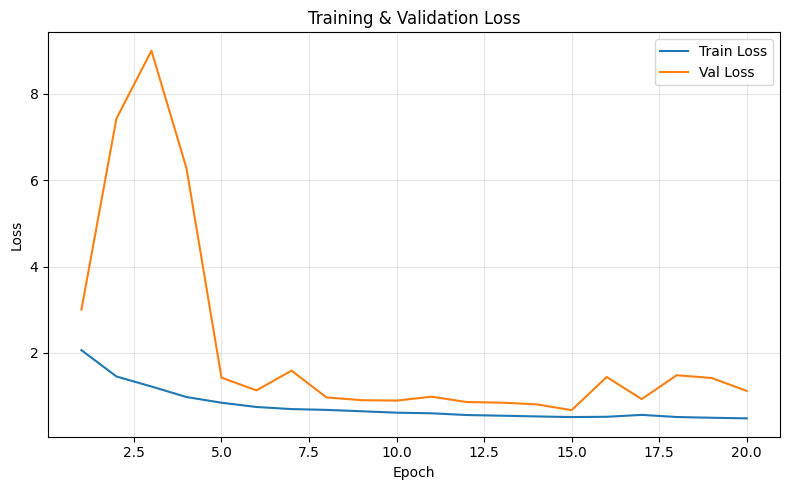

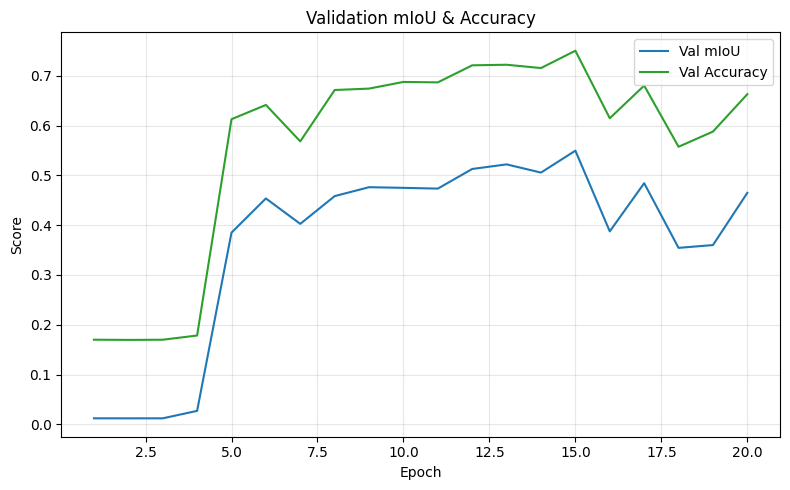

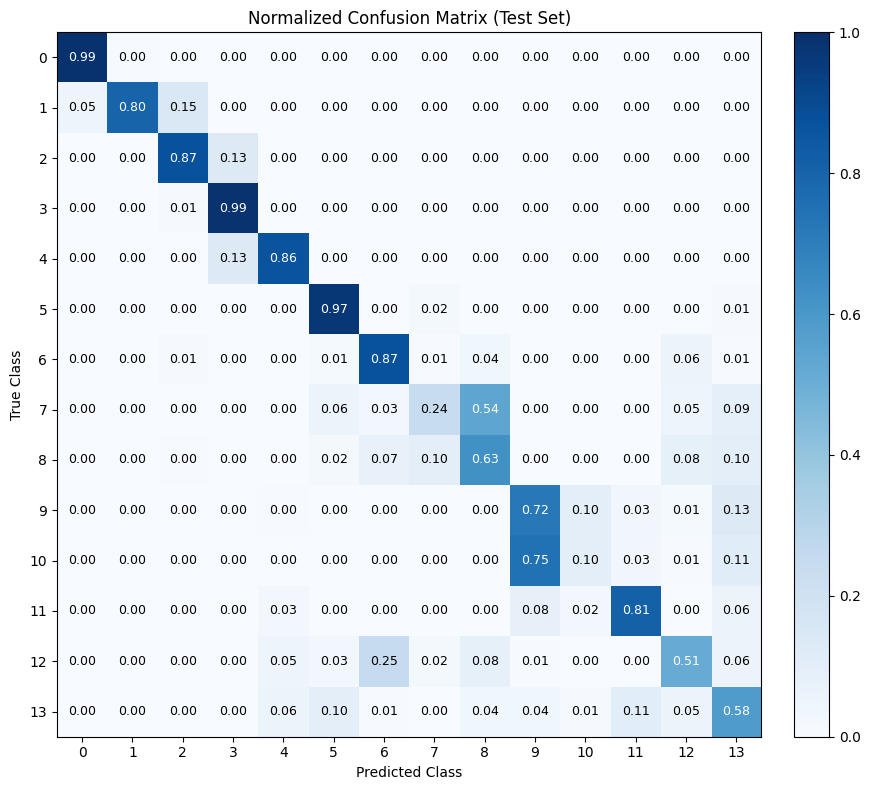


Done. Plots saved: loss_curves.png, miou_acc_curves.png, confusion_matrix.png


In [13]:
%matplotlib inline
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(epochs_range, history["train_loss"], label="Train Loss")
ax.plot(epochs_range, history["val_loss"],   label="Val Loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Training & Validation Loss")
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout(); fig.savefig("loss_curves.png", dpi=150)
plt.show()

fig, ax1 = plt.subplots(1, 1, figsize=(8, 5))
ax1.plot(epochs_range, history["val_miou"], label="Val mIoU", color="tab:blue")
ax1.plot(epochs_range, history["val_oa"],   label="Val Accuracy", color="tab:green")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Score")
ax1.set_title("Validation mIoU & Accuracy")
ax1.legend(); ax1.grid(True, alpha=0.3)
fig.tight_layout(); fig.savefig("miou_acc_curves.png", dpi=150)
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(9, 8))
cm_norm = cm.astype("float") / (cm.sum(axis=1, keepdims=True) + 1e-8)
im = ax.imshow(cm_norm, interpolation="nearest", cmap="Blues", vmin=0, vmax=1)
ax.set_title("Normalized Confusion Matrix (Test Set)")
ax.set_xlabel("Predicted Class"); ax.set_ylabel("True Class")
tick_labels = [str(i) for i in range(NUM_CLASSES)]
ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(tick_labels); ax.set_yticklabels(tick_labels)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        val = cm_norm[i, j]
        color = "white" if val > 0.5 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=9)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout(); fig.savefig("confusion_matrix.png", dpi=150)
plt.show()

print("\nDone. Plots saved: loss_curves.png, miou_acc_curves.png, confusion_matrix.png")
